In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import glob

project_dir = r'c:\Users\hbori\Documents\Itau_env\Itau-group-2'
os.chdir(project_dir)

In [3]:
# Read results.csv
results_df = pd.read_csv(os.path.join(project_dir, 'results.csv')) # batch size of 32
results_df_bs1 = pd.read_csv(os.path.join(project_dir, 'results_bs1.csv')) # batch size of 1 - more informative for latency comparison

print(f"Loaded results from results.csv")
print(f"Shape: {results_df.shape}")
print(f"Columns: {list(results_df.columns)}")
print(f"\nDataframe:")
# sort by latency_avg_ms
results_df = results_df.sort_values(by='latency_avg_ms', ascending=True).reset_index(drop=True)
print("Sorted by latency_avg_ms (top rows):")
print(results_df[['model', 'latency_avg_ms']])

print(f"\nLoaded results from results_bs1.csv")
print(f"Shape: {results_df_bs1.shape}")
print(f"Columns: {list(results_df_bs1.columns)}")
print(f"\nDataframe:")
# sort by latency_avg_ms
results_df_bs1 = results_df_bs1.sort_values(by='latency_avg_ms', ascending=True).reset_index(drop=True)
print("Sorted by latency_avg_ms (top rows):")
print(results_df_bs1[['model', 'latency_avg_ms']])  

Loaded results from results.csv
Shape: (20, 13)
Columns: ['model', 'batch_size', 'num_samples', 'total_pairs', 'num_batches', 'latency_avg_ms', 'latency_min_ms', 'latency_max_ms', 'latency_std_ms', 'throughput_pairs_per_sec', 'cpu_avg_percent', 'gpu_memory_avg_gb', 'gpu_memory_max_gb']

Dataframe:
Sorted by latency_avg_ms (top rows):
           model  latency_avg_ms
0        metrics        0.103772
1      coca_text        4.737963
2     flava_text        7.752183
3    siglip_text        9.581720
4      clip_text        9.601683
5         vitmae       71.369917
6    pytesseract       74.149942
7     clip_image       75.808259
8         resnet      125.152720
9            vit      135.378165
10  siglip_image      145.483970
11   flava_image      152.196473
12    coca_image      205.299447
13        medium      206.613844
14         small      206.891527
15         large      207.245963
16  total_5f_img      208.991513
17      total_1f      218.816237
18      total_3f      221.485138
19  

In [4]:
# Define ROC-AUC scores for each model
roc_auc_scores = {
    'metrics': 0.8908,
    'image': 0.9903,
    'large': 0.9904,
    'medium': 0.9898,
    'small': 0.9875,
    'text': 0.9782,
    'total_1f': 0.9892,
    'total_3f': 0.9912,
    'total_5f': 0.9916,
    'total_5f_img': 0.9889,
    'total_5f_mod': 0.9913,

    # from valerie
    'pytesseract': 0.89554604,

    # me
    'clip_image': 0.919742,
    'coca_image': 0.827206,
    'flava_image': 0.770026,
    'siglip_image': 0.923255,
    'clip_text': 0.611752,
    'coca_text': 0.690332 ,
    'flava_text': 0.653462,
    'siglip_text': 0.434861,

    'vit': 0.6981,
    'resnet': 0.7713,
    'vitmae': 0.5572,
}

# Add ROC-AUC scores to the results dataframe
results_df['roc_auc'] = results_df['model'].map(roc_auc_scores)
results_df_bs1['roc_auc'] = results_df_bs1['model'].map(roc_auc_scores)

print("Data for latency vs ROC-AUC plot:")
results_df

Data for latency vs ROC-AUC plot:


,model,batch_size,num_samples,total_pairs,num_batches,latency_avg_ms,latency_min_ms,latency_max_ms,latency_std_ms,throughput_pairs_per_sec,cpu_avg_percent,gpu_memory_avg_gb,gpu_memory_max_gb,roc_auc
0,metrics,32,1990,3980,63,0.103772,0.028128,0.166297,0.013586,608784.585396,0.211545,0.000000,0.000000,0.890800
1,coca_text,32,1990,3980,63,4.737963,3.763118,6.597332,0.372742,13333.704384,1.594990,0.578542,0.578542,0.690332
2,flava_text,32,1990,3980,63,7.752183,5.542688,11.917360,0.669825,8149.266150,2.245226,0.908164,0.908164,0.653462
3,siglip_text,32,1990,3980,63,9.581720,5.086335,12.982038,0.842391,6593.242365,2.510069,0.764997,0.764997,0.434861
4,clip_text,32,1990,3980,63,9.601683,6.074192,12.207269,0.628125,6579.534188,2.873636,0.571977,0.571977,0.611752
5,vitmae,32,1990,3980,63,71.369917,16.575522,76.509515,7.010152,885.171319,3.698177,0.328536,0.328536,0.557200
6,pytesseract,32,1990,3980,63,74.149942,13.806996,76.675764,7.689736,851.984528,2.700186,0.007935,0.007935,0.895546
7,clip_image,32,1990,3980,63,75.808259,21.041225,80.704391,7.026988,833.347241,3.576897,0.574418,0.574418,0.919742
8,resnet,32,1990,3980,63,125.152720,75.694303,183.145268,9.612749,504.780107,3.056052,0.096715,0.096715,0.771300
9,vit,32,1990,3980,63,135.378165,29.019143,141.810443,13.574848,466.652826,3.220052,0.329760,0.329760,0.698100


# roc auc vs latency

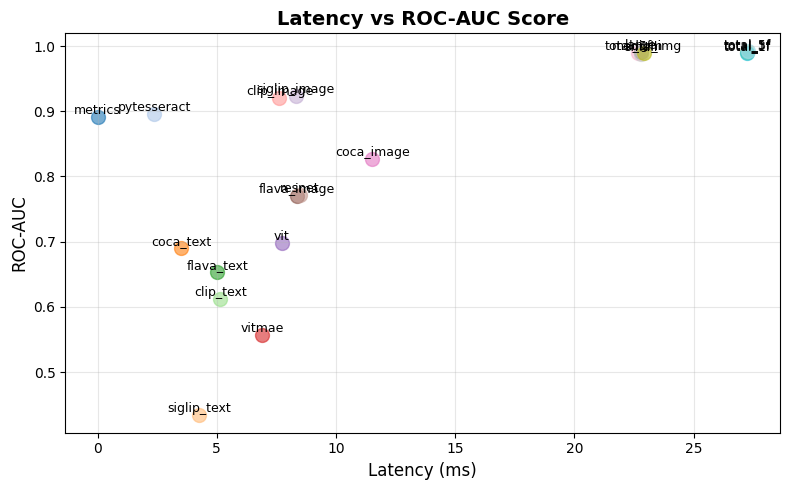

In [7]:
# Create scatter plot: Latency vs ROC-AUC. Make each model a new color and add labels to each point
plot_data = results_df_bs1.drop_duplicates(subset=['model']).copy()

plt.figure(figsize=(8, 5))

# colors = plt.cm.viridis(np.linspace(0, 1, len(plot_data)))
# more distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_data)))

for i, row in plot_data.iterrows():
    plt.scatter(row['latency_avg_ms'], row['roc_auc'], s=100, alpha=0.6, color=colors[i])

# Add model labels to each point
for _, row in plot_data.iterrows():
    plt.text(row['latency_avg_ms'], row['roc_auc'], row['model'], fontsize=9, ha='center', va='bottom')

plt.xlabel('Latency (ms)', fontsize=12)
plt.ylabel('ROC-AUC', fontsize=12)
plt.title('Latency vs ROC-AUC Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.legend(['Models'], loc='lower right')
plt.show()

# roc auc vs throughput

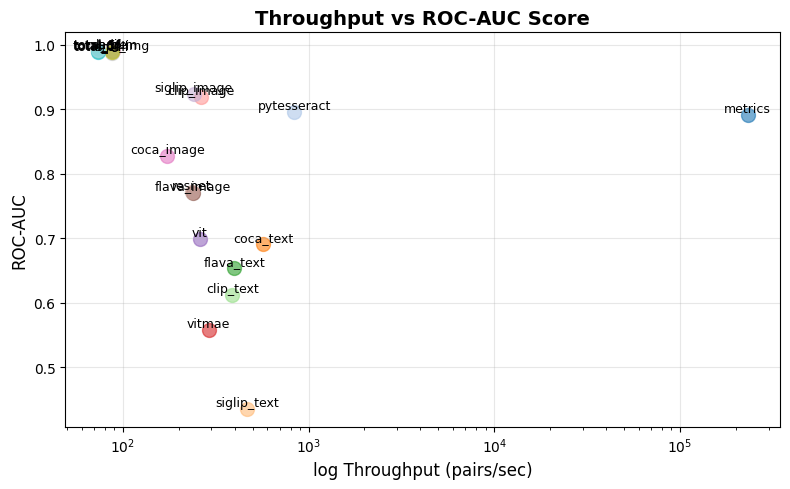

In [10]:
# Create scatter plot: Latency vs ROC-AUC. Make each model a new color and add labels to each point
plot_data = results_df_bs1.drop_duplicates(subset=['model']).copy()

plt.figure(figsize=(8, 5))

# colors = plt.cm.viridis(np.linspace(0, 1, len(plot_data)))
# more distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_data)))

for i, row in plot_data.iterrows():
    plt.scatter(row['throughput_pairs_per_sec'], row['roc_auc'], s=100, alpha=0.6, color=colors[i])

# Add model labels to each point
for _, row in plot_data.iterrows():
    plt.text(row['throughput_pairs_per_sec'], row['roc_auc'], row['model'], fontsize=9, ha='center', va='bottom')

# log scale for x axis
plt.xscale('log')

plt.xlabel('log Throughput (pairs/sec)', fontsize=12)
plt.ylabel('ROC-AUC', fontsize=12)
plt.title('Throughput vs ROC-AUC Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()